In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/placement.csv')

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (in LPA)')

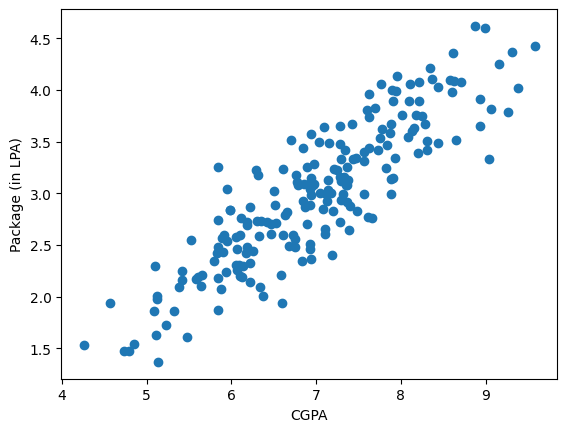

In [6]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in LPA)')

In [7]:
# Selects all rows, start at column 0 and stop before column 1
X = df.iloc[:,0:1] # So it selects only column 0
# Selects all rows Selects the last column This becomes the output/target (y)
y = df.iloc[:,-1]

In [8]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [9]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [10]:
# train test split
from sklearn.model_selection import train_test_split
# random_state is used to control randomness so results stay the same every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=2)

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
lr = LinearRegression()

In [13]:
lr.fit(X_train, y_train)

LinearRegression()

In [14]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [15]:
y_test

,package
112,4.10
29,3.49
182,2.08
199,2.33
193,1.94
85,1.48
10,1.86
54,3.09
115,4.21
35,2.87


In [33]:
lr.predict(X_test.iloc[0:1])

array([3.89111601])

Text(0, 0.5, 'Package (in LPA)')

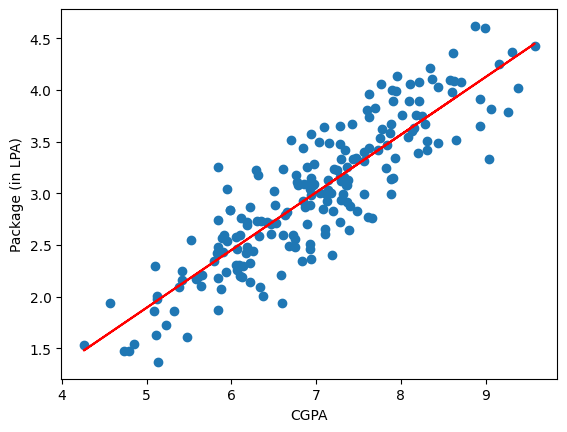

In [26]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color = 'red')
plt.xlabel('CGPA')
plt.ylabel('Package (in LPA)')

In [28]:
# gives the slope (weight) of the feature in the
# trained Linear Regression model, showing how much
# output changes when input increases by 1 unit.
m = lr.coef_

In [30]:
# gives the constant value (c) in Linear Regression,
# i.e., the predicted output when all input features are 0.
b = lr.intercept_

In [31]:
# y = mx + b

m * 8.5 + b

array([3.84647985])

In [32]:
m * 100 + b

array([54.89908542])

In [34]:
print("Equation: y = ", m[0], "x +", b)

Equation: y =  0.557951973425072 x + -0.8961119222429144


In [36]:
y_pred = lr.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.2884710931878175
0.12129235313495527
